In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["LANGCHAIN_PROJECT"] = "subgraph"
os.environ["LANGCHAIN_TRACING_V2"] = "true"

In [2]:
# ================= TYPES =================
from typing import TypedDict, Literal, Annotated

# ================= LANGCHAIN CORE =================
from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, BaseMessage, HumanMessage

# ================= MODELS =================
from langchain_openai import ChatOpenAI, OpenAI
from langchain_huggingface import HuggingFaceEmbeddings

# ================= VECTOR STORES =================
from langchain_community.vectorstores import FAISS
from langchain_chroma import Chroma

# ================= UTILITIES =================
from youtube_transcript_api import YouTubeTranscriptApi
from langchain_text_splitters import RecursiveCharacterTextSplitter

# ================= LANGGRAPH =================
from langgraph.graph import StateGraph, START, END

D:\code floders\PYTHON-5\LANGCHAIN_MODELS\new_environment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
os.environ["OPENROUTER_API_KEY"]="sk-or-v1-8015337cd089e7b362f973bc14e0a12f5463a727ccbde806"



In [4]:
model = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    model="openrouter/free",
    temperature=0.7,
)

In [35]:
class SubState(TypedDict):
    input_text:str
    translated_text:str

In [36]:
subgraph_llm= model

In [37]:
def translate_text(state:SubState):
    prompt=f"""
translate the following text to hindi.
keep it neutral and clear. do not add extra content

text :
{ state["input_text"]}
""".strip()

    translated_text=subgraph_llm.invoke(prompt).content

    return {'translated_text':translated_text}
    



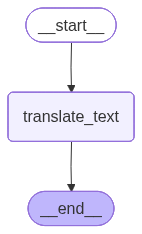

In [38]:
subgraph_builder=StateGraph(SubState)

subgraph_builder.add_node('translate_text',translate_text)

subgraph_builder.add_edge(START,'translate_text')
subgraph_builder.add_edge('translate_text',END)
subgraph=subgraph_builder.compile()
subgraph

In [39]:
class ParentState(TypedDict):
    question :str
    answer_eng:str
    answer_hin:str

In [40]:
parent_llm=model


In [41]:
def generate_answer(state:ParentState):
    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}


In [42]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}


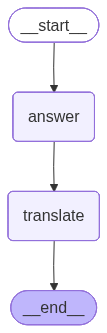

In [43]:
parent_builder=StateGraph(ParentState)
parent_builder.add_node("answer",generate_answer)
parent_builder.add_node("translate",translate_answer)
parent_builder.add_edge(START,'answer')
parent_builder.add_edge('answer','translate')
parent_builder.add_edge('translate',END)

graph=parent_builder.compile()
graph

In [44]:
answer=graph.invoke({'question': 'What is quantum physics'})


In [45]:
answer

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics (or quantum mechanics) is the fundamental branch of physics that describes the behavior of matter and energy at the **smallest scales** – primarily the atomic and subatomic level (like electrons, photons, atoms, and their constituent particles).\n\nHere\'s a clear breakdown of its core ideas and why it\'s important:\n\n1.  **It Deals with the Tiny:** While classical physics (Newton\'s laws, Maxwell\'s equations) works perfectly for everyday objects (baseballs, cars, planets), it fails to explain phenomena at the atomic scale. Quantum physics takes over.\n\n2.  **Key Principles:**\n    *   **Quantization:** Unlike classical physics where properties like energy can take *any* value, quantum physics dictates that certain properties (like energy, angular momentum, charge) can only exist in specific, discrete amounts or "packets." These packets are called **quanta** (singular: quantum). For example, an electron in an at